In [61]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm
from torch.utils.data import random_split
from torchmetrics.regression import MeanSquaredError
from matplotlib.gridspec import GridSpec

In [62]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
# TODO: Why empyrically picked 25?
BITS_HIT = 25 

In [63]:
def show_image(events: np.array) -> None:
    image_plot = events.to_images()[0][1]
    plt.imshow(image_plot, cmap='gist_yarg', origin='lower')
    plt.show()
    
def _tensor_to_numpy(values: torch.Tensor) -> np.array:
    return values.cpu().detach().numpy()

def plot_patch(patch: np.array, title: str) -> None:
    plt.imshow(patch, cmap='gist_yarg', origin='lower')
    plt.title(title)
    plt.show()
    
def _get_encoded_patch_bits(encoded_size,
                           patch_size,
                           module_rows=160,
                           module_cols=416):
    
    encoded_width, encoded_height, num_embeddings = encoded_size
    
    # np.log2(num_embeddings) - how many bits for specific codeword    
    vq_bits = encoded_width * encoded_height * np.log2(num_embeddings)
    
    # Patch address bits
    bits_patch_row = np.ceil(np.log2(np.ceil(module_rows / patch_size)))
    bits_patch_col = np.ceil(np.log2(np.ceil(module_cols / patch_size)))
    total = bits_patch_row + bits_patch_col + vq_bits
    
    # 267 % 256 = 11
    return total

def _get_total_hit_bits(total_hits: int) -> int:
    
    # Patch address bits
    return total_hits * BITS_HIT

"""
Method for getting patch bits

patch_amount - total detector patch count

encoded_patch_size - encoded_width, encoded_height, num_embeddings

patch_size - patch size
"""

def _get_total_patch_bits(patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> int:
    encoded_patch_bits = _get_encoded_patch_bits(encoded_patch_size, patch_size)
    return np.uint64(patch_amount * encoded_patch_bits)

def _get_compression_ratio(n_hits_total: int, patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> float:
    total_bits = _get_total_hit_bits(n_hits_total)
    
    total_patch_bits = _get_total_patch_bits(
        patch_amount, 
        encoded_patch_size, 
        patch_size
    )
    return total_bits / total_patch_bits

def _get_patch_count(event: PixelDigiEvent) -> int:
    event_patches_adcs_flat = event_hits_to_patches(
        event, 
        patch_size=PATCH_SIZE
    ).as_array()
    return len(event_patches_adcs_flat)
    
# helper function
def _display_gradients(model: object) -> None:
    print("Showing model gradients")
    for name, param in model.named_parameters():
        if param.grad is not None:
            print(name, param.grad.norm().item())
            
def plot_metric_results(
    y_values: list[float], 
    x_values: int, 
    y_title: str, 
    title: str,
    x_label: str,
    marker: str=None
) -> None:
    print(title + " values over epochs")
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(8, 5))
    plt.plot(x_values, y_values, marker=marker)
    plt.xlabel(x_label)
    plt.ylabel(y_title)
    plt.legend()
    plt.title(title)
    plt.show()

In [64]:
# Loading data

pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:04<00:00, 244.16it/s]


In [65]:
batch_size = 64
beta = 0.35
# beta = 0.98

# beta = 1 0.
# beta is possible in interval [4e-3, 8e-3]

# 0.1, 0.08 - on the right track

learning_rate = 1e-3
model_param_scale = 5
# model_param_scale = 1 (right order)
# learning_rate = 1e-3 (right on track)

num_epochs = 80

# input channels
channels = 1
hidden_channels = 64
latent_dim = 256
# latent_dim = 64 (on track)

# how many codebook entries
num_embeddings = 32
# num_embeddings = 32 (on track)

# logs
LOG_EVERY = 15


In [66]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [67]:
mse = MeanSquaredError()
mse = mse.to(device)

In [68]:
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

In [69]:
event_train = events_train[:SELECTED_EVENTS][0]

In [70]:
patch_amount = _get_patch_count(event_train)
total_hit_amount = len(event_train)

print(f"Total patch amount: {patch_amount}")
print(f"Total hits: {total_hit_amount}")

Total patch amount: 15857
Total hits: 48169


In [71]:
class PixelPatchesDataset(torch.utils.data.Dataset):
    def __init__(self, event: PixelDigiEvent, transform=None):
        event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
        self.event_patches_adcs = [
            event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
            for event_patch_flat in event_patches_adcs_flat
            if not (np.all(event_patch_flat == 0))
        ]
        
        self.transform = transform

    # Defining the length of the dataset
    def __len__(self) -> int:
        return len(self.event_patches_adcs)

    # Defining the method to get an item from the dataset
    def __getitem__(self, index: int) -> np.array:
        # print(self.event_patches_adcs[index])
        event_patch = self.event_patches_adcs[index]
        
        # Applying the transform
        if self.transform:
            event_patch = self.transform(event_patch)
            # print(event_patch)
        
        return event_patch

In [72]:
# Data preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
])

event_dataset = PixelPatchesDataset(event_train, transform)
dataset_size = len(event_dataset)

train_size = int(0.8 * dataset_size)
val_size = int(0.1 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    event_dataset,
    [train_size, val_size, test_size]
)

# # Training data prepearation

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset, 
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=batch_size,
    shuffle=False
)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")


# EXAMPLE with events test
# train_loader = DataLoader(
#     dataset=event_dataset, 
#     batch_size=batch_size
# )

# # Test data preparation
# events_test_loaders = []
# for event_test in events_test:
#     event_dataset = PixelPatchesDataset(event_test, transform)

#     event_test_loader = DataLoader(
#         dataset=event_dataset, 
#         batch_size=batch_size
#     )
#     events_test_loaders.append(event_test_loader)

Training set size: 12685
Validation set size: 1585
Test set size: 1587


In [73]:
def _get_vae_loss(
    recon_x: torch.tensor, 
    x: torch.tensor
) -> float:
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="mean")
    return recon_loss
    # # KL_divergence
    # kl_loss = -0.5 * (
    #     1 + logvar - mu.pow(2) - logvar.exp()
    # )
    
    # kl_loss = kl_loss.mean()
    
    # return (
    #     recon_loss + beta * kl_loss,
    #     recon_loss,
    #     beta,
    #     kl_loss
    # )

In [74]:
# Goal of Vector Quantization is to solve posterior collapse problem

class VectorQuantizer(nn.Module):
    """
    Discretization bottleneck part of the VQ-VAE.

    Inputs:
    - n_e : number of embeddings
    - e_dim : dimension of embedding
    - beta : commitment cost used in loss term, beta * ||z_e(x)-sg[e]||^2
    """

    def __init__(self, n_e, e_dim, beta):
        super(VectorQuantizer, self).__init__()
        self.n_e = n_e
        self.e_dim = e_dim
        self.beta = beta

        self.embedding = nn.Embedding(self.n_e, self.e_dim)
        self.embedding.weight.data.uniform_(-1.0 / self.n_e, 1.0 / self.n_e)

    def forward(self, z):
        """
        Inputs the output of the encoder network z and maps it to a discrete
        one-hot vector that is the index of the closest embedding vector e_j

        z (continuous) -> z_q (discrete)

        z.shape = (batch, channel, height, width)

        quantization pipeline:

            1. get encoder input (B,C,H,W)
            2. flatten input to (B*H*W,C)

        """
        # reshape z -> (batch, height, width, channel) and flatten
        z = z.permute(0, 2, 3, 1).contiguous()
        z_flattened = z.view(-1, self.e_dim)
        # distances from z to embeddings e_j (z - e)^2 = z^2 + e^2 - 2 e * z

        # TODO: Proove that (z_flattened - weight) ** 2 is inefficient and gives huge matrix
        # NOTE: is a matrix learnable vector for learning codebook indices
        codebook = self.embedding.weight
        
        # Euclidean distance for finding closest codebooks
        d = torch.sum(z_flattened ** 2, dim=1, keepdim=True) + \
            torch.sum(self.embedding.weight**2, dim=1) - 2 * \
            torch.matmul(z_flattened, codebook.t())
            
        # Result -> d gets dimensions from matrix torch.matmul(z_flattened, self.embedding.weight.t())
        # embedding weight t is defined by num_embeddings, latent_dim
        # --------------------
            
        # also it is possible to find closest codebooks by a probability distributions
        # https://arxiv.org/html/2602.02726v1

        # find closest encodings
        min_encoding_indices = torch.argmin(d, dim=1).unsqueeze(1)
        min_encodings = torch.zeros(
            min_encoding_indices.shape[0], self.n_e).to(device)
        
        # perform one hot encoding
        min_encodings.scatter_(1, min_encoding_indices, 1)

        # NOTE: selects weights form embedding weight and puts them based on one hot encoding
        z_q = torch.matmul(min_encodings, codebook).view(z.shape)
        
        # beta - commitment cost used in loss term
        
        # compute loss for embedding
        loss = torch.mean((z_q.detach() - z)**2) + self.beta * \
            torch.mean((z_q - z.detach()) ** 2)

        # preserve gradients with preservation trick. Allows gradients to exist
        # (z_q - z.detach() )- is like a constant

        # We make quantized latent space vector to get closer to the encoder output
        # we highliht the codewords and gradually each epoch we force neaigoboring pixels
        # to be associating with cendroids
        z_q = z + (z_q - z).detach()

        # perplexity - average of weights of probabilities
        e_mean = torch.mean(min_encodings, dim=0)
        
        # Measures how many codebook vectors are beeing used
        perplexity = torch.exp(-torch.sum(e_mean * torch.log(e_mean + 1e-10)))

        # reshape back to match original input shape
        # contiguous() is used for improving performance
        z_q = z_q.permute(0, 3, 1, 2).contiguous()

        return loss, z_q, perplexity, min_encodings, min_encoding_indices, codebook

In [75]:
class ResidualLayer(nn.Module):
    """
    One residual layer inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    """

    def __init__(self, in_dim, h_dim, res_h_dim):
        super(ResidualLayer, self).__init__()
        self.res_block = nn.Sequential(
            nn.LeakyReLU(True),
            nn.Conv2d(in_dim, res_h_dim, kernel_size=3,
                      stride=1, padding=1, bias=False),
            nn.LeakyReLU(True),
            nn.Conv2d(res_h_dim, h_dim, kernel_size=1,
                      stride=1, bias=False)
        )

    def forward(self, x):
        x = x + self.res_block(x)
        return x


class ResidualStack(nn.Module):
    """
    A stack of residual layers inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    - n_res_layers : number of layers to stack
    """

    def __init__(self, in_dim, h_dim, res_h_dim, n_res_layers):
        super(ResidualStack, self).__init__()
        self.n_res_layers = n_res_layers
        self.stack = nn.ModuleList(
            [
                ResidualLayer(in_dim, h_dim, res_h_dim)
                for _ in range(n_res_layers)
            ])

    def forward(self, x):
        for layer in self.stack:
            x = layer(x)
        x = F.relu(x)
        return x

In [76]:
# Comments
# kernel_size = 4 - preserves spatial repesentations (coordinates)
class VQVAE(nn.Module):
    
    def __init__(
        self, 
        hidden_channels: int, 
        kernel_size: int, 
        slope: float,
        res_h_dim: int,
        n_res_layers: int
    ) -> None:
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),  
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),            
            nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=kernel_size-1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, latent_dim),
            # nn.LeakyReLU(slope),
            ResidualStack(latent_dim, latent_dim, res_h_dim, n_res_layers)
        )
        
        self.vq_layer = VectorQuantizer(num_embeddings, latent_dim, beta)
        
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=kernel_size - 1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            ResidualStack(hidden_channels * 2, hidden_channels * 2, res_h_dim, n_res_layers),
            # nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels, channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.Sigmoid()
        )
    
    # def reparameterize(self, mu, logvar):
    #     return mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        
        
    def forward(self, x):
        # apply convolutional layers with relu activation function
        # print("x range:", x.min().item(), x.max().item())
        
        z_encoded = self.encoder(x)
        
        # x_flatten = self.flatten(x_encoded)
        
        # get the mean and log variance of the latent space distribution
        # z_log_mean = self.fc_mean(x_encoded)
        # z_log_var = self.fc_log_var(x_encoded)
        
        # self.z_log_mean = torch.clamp(z_log_mean, min=-10, max=10)
        # self.z_log_var = torch.clamp(z_log_var, min=-8, max=1)
        # self.z_log_var = torch.tanh(z_log_var) * 8
        
        # sample a latent vector using the reparameterization trick
        
        # z = self.reparameterize(self.z_log_mean, self.z_log_var)
        
        (
            recon_loss, 
            z_q, 
            perplexity, 
            min_encodings, 
            min_encoding_indices, 
            codebook
        ) = self.vq_layer(z_encoded)
        
        output = self.decoder(z_q)
        
        return output, codebook, z_q, perplexity, recon_loss

In [77]:
model = VQVAE(
    hidden_channels=hidden_channels, 
    kernel_size = 4,
    slope=0.01,
    n_res_layers=2,
    res_h_dim=32
).to(device)

optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

Epoch 1/80: 100%|██████████| 199/199 [00:00<00:00, 398.16it/s, Loss (BCE + VQ)=0.0985]


Epoch [1/80]Average Loss: BCE = 0.1394, MSE = 0.00814727815359494 avg_perplexity = 9.620144100045438
Average validation set BCE loss: 0.05700755849480629
Before compression (Training)
Shape: (13, 8, 8)


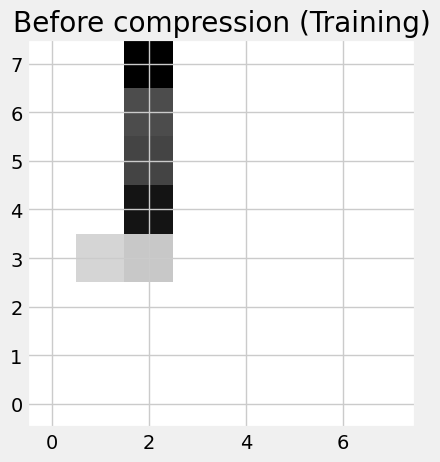

After compression (Training)
Shape: (1, 8, 8)


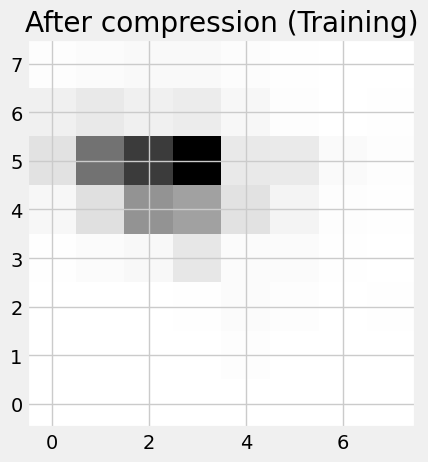

Before compression (Validation)
Shape: (64, 8, 8)


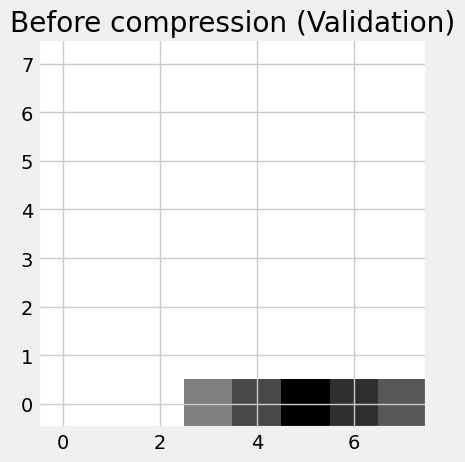

After compression (Validation)
Shape: (1, 8, 8)


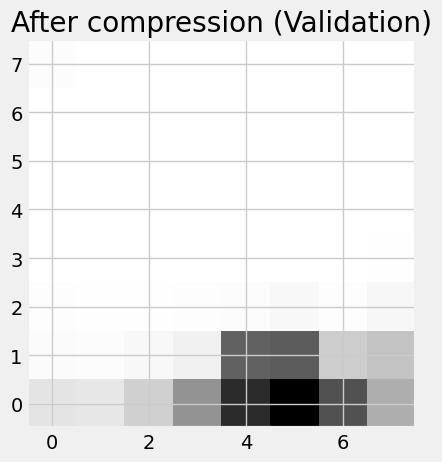

----------------------------------------
Patch = 0 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 2.449767783435422
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 31.0 (1 patch 8 x 8)
num_embeddings = 32
Codebook dimensions: 32 x 256
----------------------------------------


Epoch 2/80: 100%|██████████| 199/199 [00:00<00:00, 404.47it/s, Loss (BCE + VQ)=0.0585]


Epoch [2/80]Average Loss: BCE = 0.0763, MSE = 0.005380408198399534 avg_perplexity = 16.04700474283803
Average validation set BCE loss: 0.04865157201886177


Epoch 3/80: 100%|██████████| 199/199 [00:00<00:00, 401.09it/s, Loss (BCE + VQ)=0.0433]


Epoch [3/80]Average Loss: BCE = 0.0642, MSE = 0.004604310926340108 avg_perplexity = 17.626757693650134
Average validation set BCE loss: 0.04573717474937439


...

Epoch [14/80]Average Loss: BCE = 0.0427, MSE = 0.0028327563520165245 avg_perplexity = 25.17351627829087
Average validation set BCE loss: 0.037535189837217334


Epoch 15/80: 100%|██████████| 199/199 [00:00<00:00, 390.00it/s, Loss (BCE + VQ)=0.0532]


Epoch [15/80]Average Loss: BCE = 0.0421, MSE = 0.002790650414260825 avg_perplexity = 25.200362938732358
Average validation set BCE loss: 0.03756656318902969


Epoch 16/80: 100%|██████████| 199/199 [00:00<00:00, 396.25it/s, Loss (BCE + VQ)=0.0616]


Epoch [16/80]Average Loss: BCE = 0.0419, MSE = 0.0027767134439574564 avg_perplexity = 24.95251782096211
Average validation set BCE loss: 0.03739781975746155
Before compression (Training)
Shape: (13, 8, 8)


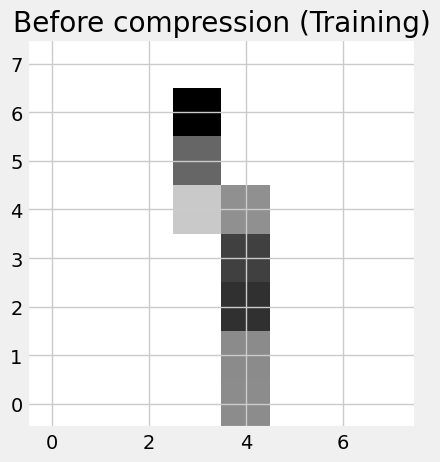

After compression (Training)
Shape: (1, 8, 8)


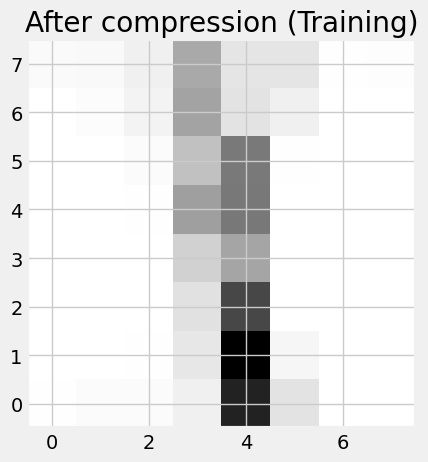

Before compression (Validation)
Shape: (64, 8, 8)


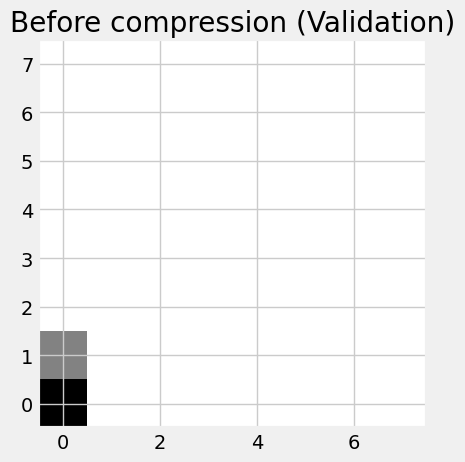

After compression (Validation)
Shape: (1, 8, 8)


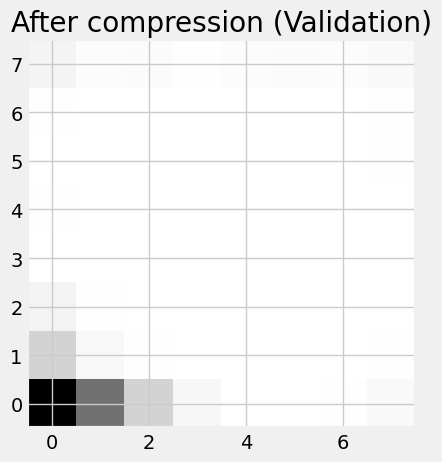

----------------------------------------
Patch = 1 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 2.449767783435422
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 31.0 (1 patch 8 x 8)
num_embeddings = 32
Codebook dimensions: 32 x 256
----------------------------------------


Epoch 17/80: 100%|██████████| 199/199 [00:00<00:00, 398.91it/s, Loss (BCE + VQ)=0.0495]


Epoch [17/80]Average Loss: BCE = 0.0416, MSE = 0.002730237747116679 avg_perplexity = 24.971220361527486
Average validation set BCE loss: 0.03764548681676388


Epoch 18/80: 100%|██████████| 199/199 [00:00<00:00, 406.11it/s, Loss (BCE + VQ)=0.0309]


Epoch [18/80]Average Loss: BCE = 0.0412, MSE = 0.0026781453304086347 avg_perplexity = 24.90208743684855
Average validation set BCE loss: 0.03694524049758911


...

Epoch [29/80]Average Loss: BCE = 0.0390, MSE = 0.0023631006841964308 avg_perplexity = 24.591845689706467
Average validation set BCE loss: 0.036726189479231834


Epoch 30/80: 100%|██████████| 199/199 [00:00<00:00, 403.53it/s, Loss (BCE + VQ)=0.0357]


Epoch [30/80]Average Loss: BCE = 0.0389, MSE = 0.002354086356251571 avg_perplexity = 24.620818267515556
Average validation set BCE loss: 0.03625824525952339


Epoch 31/80: 100%|██████████| 199/199 [00:00<00:00, 407.17it/s, Loss (BCE + VQ)=0.0315]


Epoch [31/80]Average Loss: BCE = 0.0384, MSE = 0.002304355313196479 avg_perplexity = 24.62129770211838
Average validation set BCE loss: 0.036130294501781464
Before compression (Training)
Shape: (13, 8, 8)


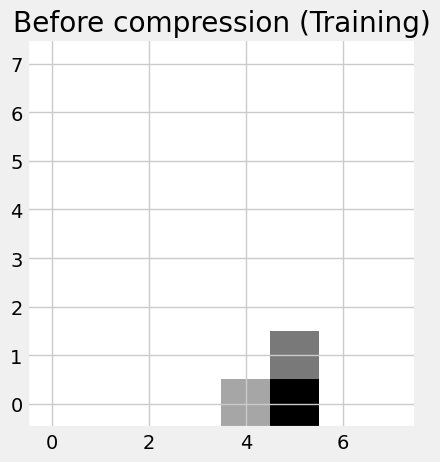

After compression (Training)
Shape: (1, 8, 8)


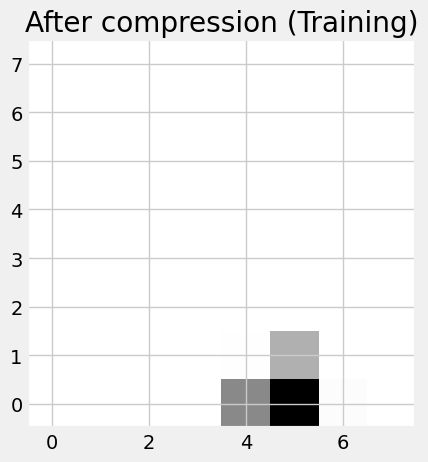

Before compression (Validation)
Shape: (64, 8, 8)


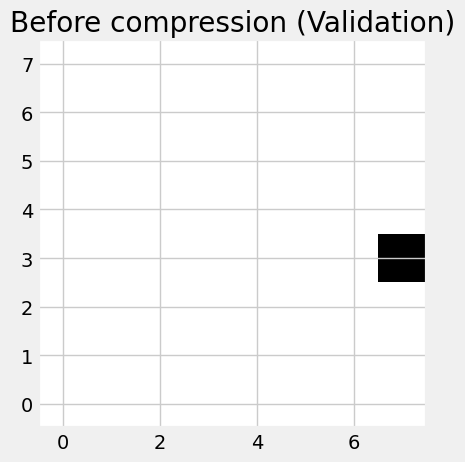

After compression (Validation)
Shape: (1, 8, 8)


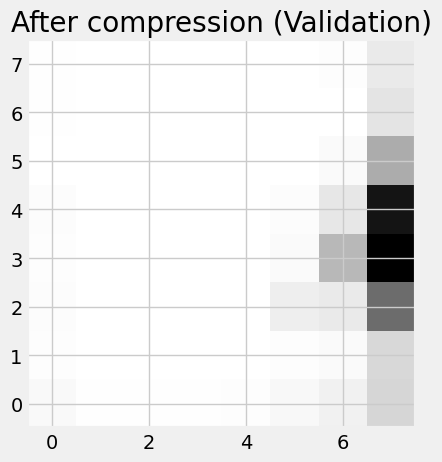

----------------------------------------
Patch = 2 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 2.449767783435422
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 31.0 (1 patch 8 x 8)
num_embeddings = 32
Codebook dimensions: 32 x 256
----------------------------------------


Epoch 32/80: 100%|██████████| 199/199 [00:00<00:00, 406.32it/s, Loss (BCE + VQ)=0.0555]


Epoch [32/80]Average Loss: BCE = 0.0385, MSE = 0.002308843278878336 avg_perplexity = 24.62313995169635
Average validation set BCE loss: 0.0363532592356205


Epoch 33/80: 100%|██████████| 199/199 [00:00<00:00, 405.48it/s, Loss (BCE + VQ)=0.0507]


Epoch [33/80]Average Loss: BCE = 0.0384, MSE = 0.0023053441975902224 avg_perplexity = 24.614021071237534
Average validation set BCE loss: 0.03674808159470558


...

Epoch [44/80]Average Loss: BCE = 0.0369, MSE = 0.002057496518547174 avg_perplexity = 24.53933643935314
Average validation set BCE loss: 0.036821233704686165


Epoch 45/80: 100%|██████████| 199/199 [00:00<00:00, 403.19it/s, Loss (BCE + VQ)=0.0232]


Epoch [45/80]Average Loss: BCE = 0.0369, MSE = 0.0020289650729777824 avg_perplexity = 24.436129632307658
Average validation set BCE loss: 0.03693770475685596


Epoch 46/80: 100%|██████████| 199/199 [00:00<00:00, 403.91it/s, Loss (BCE + VQ)=0.049] 


Epoch [46/80]Average Loss: BCE = 0.0367, MSE = 0.0020171512455337834 avg_perplexity = 24.554432892919184
Average validation set BCE loss: 0.03644034951925278
Before compression (Training)
Shape: (13, 8, 8)


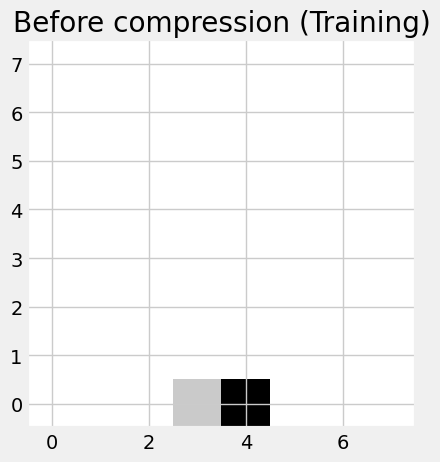

After compression (Training)
Shape: (1, 8, 8)


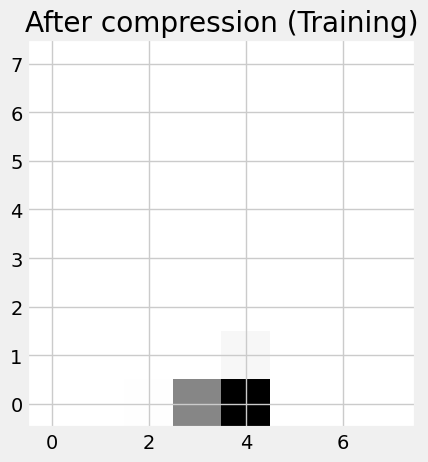

Before compression (Validation)
Shape: (64, 8, 8)


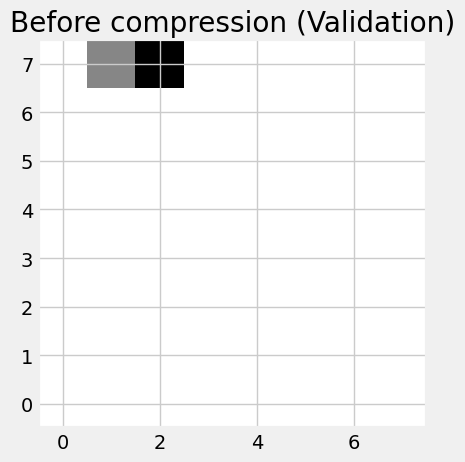

After compression (Validation)
Shape: (1, 8, 8)


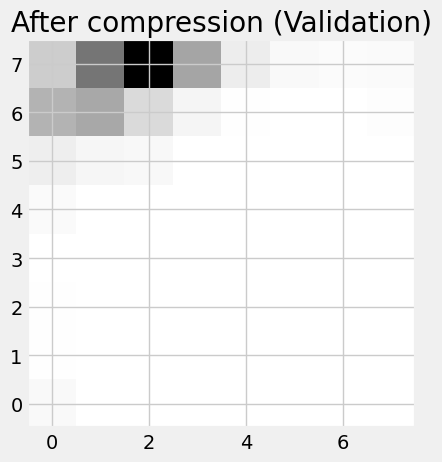

----------------------------------------
Patch = 3 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 2.449767783435422
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 31.0 (1 patch 8 x 8)
num_embeddings = 32
Codebook dimensions: 32 x 256
----------------------------------------


Epoch 47/80: 100%|██████████| 199/199 [00:00<00:00, 396.31it/s, Loss (BCE + VQ)=0.0355]


Epoch [47/80]Average Loss: BCE = 0.0365, MSE = 0.0019831498198552835 avg_perplexity = 24.53696292129593
Average validation set BCE loss: 0.036822968795895576


Epoch 48/80: 100%|██████████| 199/199 [00:00<00:00, 401.29it/s, Loss (BCE + VQ)=0.033] 


Epoch [48/80]Average Loss: BCE = 0.0366, MSE = 0.0020058027459261703 avg_perplexity = 24.514167756890533
Average validation set BCE loss: 0.03655485831201077


...

Epoch [59/80]Average Loss: BCE = 0.0356, MSE = 0.0018102796742430509 avg_perplexity = 24.610535070524744
Average validation set BCE loss: 0.036817429140210155


Epoch 60/80: 100%|██████████| 199/199 [00:00<00:00, 403.43it/s, Loss (BCE + VQ)=0.0371]


Epoch [60/80]Average Loss: BCE = 0.0355, MSE = 0.0017963952558049604 avg_perplexity = 24.691664873056077
Average validation set BCE loss: 0.03666592225432396


Epoch 61/80: 100%|██████████| 199/199 [00:00<00:00, 408.28it/s, Loss (BCE + VQ)=0.0263]


Epoch [61/80]Average Loss: BCE = 0.0354, MSE = 0.0018046373046873765 avg_perplexity = 24.713055663372405
Average validation set BCE loss: 0.037024250254034996
Before compression (Training)
Shape: (13, 8, 8)


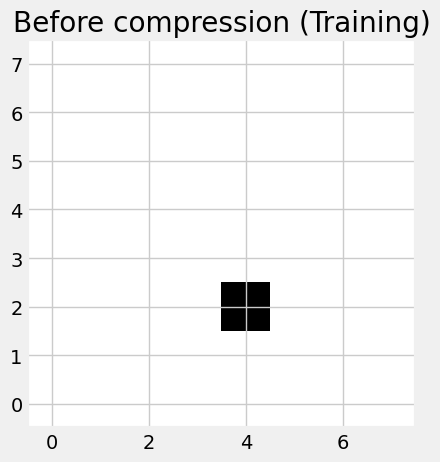

After compression (Training)
Shape: (1, 8, 8)


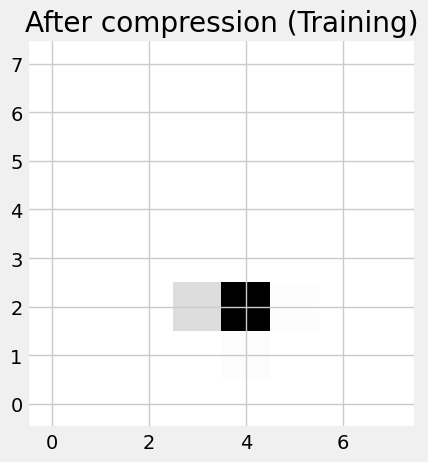

Before compression (Validation)
Shape: (64, 8, 8)


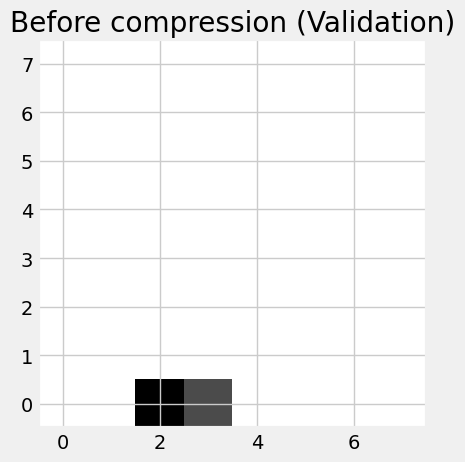

After compression (Validation)
Shape: (1, 8, 8)


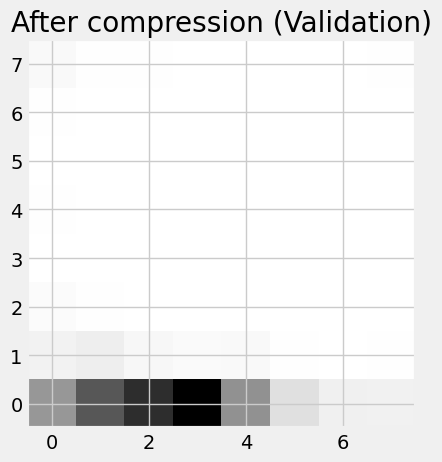

----------------------------------------
Patch = 4 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 2.449767783435422
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 31.0 (1 patch 8 x 8)
num_embeddings = 32
Codebook dimensions: 32 x 256
----------------------------------------


Epoch 62/80: 100%|██████████| 199/199 [00:00<00:00, 407.47it/s, Loss (BCE + VQ)=0.0294]


Epoch [62/80]Average Loss: BCE = 0.0354, MSE = 0.001790179200318347 avg_perplexity = 24.72492762426635
Average validation set BCE loss: 0.03710307843983173


Epoch 63/80: 100%|██████████| 199/199 [00:00<00:00, 395.79it/s, Loss (BCE + VQ)=0.0429]


Epoch [63/80]Average Loss: BCE = 0.0356, MSE = 0.0018293981863906485 avg_perplexity = 24.635250436600728
Average validation set BCE loss: 0.03676213540136814


...

Epoch [74/80]Average Loss: BCE = 0.0350, MSE = 0.0016791491863439468 avg_perplexity = 24.771444502787375
Average validation set BCE loss: 0.036546649560332295


Epoch 75/80: 100%|██████████| 199/199 [00:00<00:00, 401.27it/s, Loss (BCE + VQ)=0.0502]


Epoch [75/80]Average Loss: BCE = 0.0347, MSE = 0.0016261860836489154 avg_perplexity = 24.736393722457503
Average validation set BCE loss: 0.03683793745934963


Epoch 76/80: 100%|██████████| 199/199 [00:00<00:00, 404.12it/s, Loss (BCE + VQ)=0.039] 


Epoch [76/80]Average Loss: BCE = 0.0348, MSE = 0.0016212822692749562 avg_perplexity = 24.760045018028375
Average validation set BCE loss: 0.037130029946565626
Before compression (Training)
Shape: (13, 8, 8)


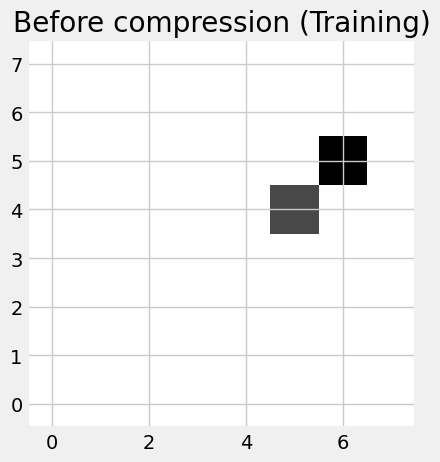

After compression (Training)
Shape: (1, 8, 8)


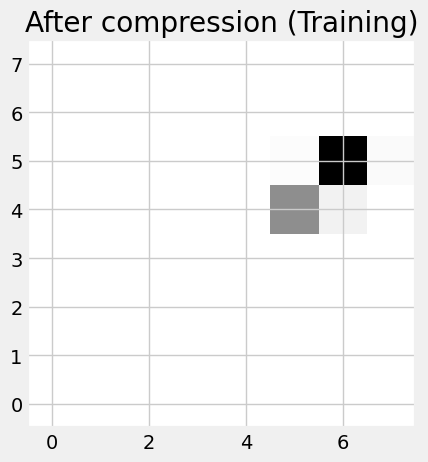

Before compression (Validation)
Shape: (64, 8, 8)


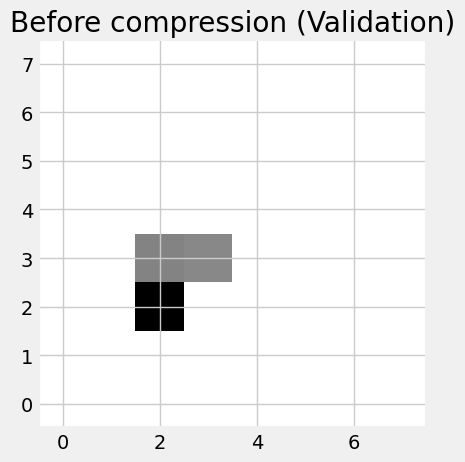

After compression (Validation)
Shape: (1, 8, 8)


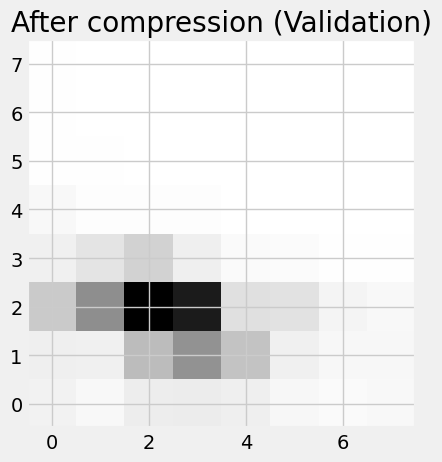

----------------------------------------
Patch = 5 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 2.449767783435422
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 31.0 (1 patch 8 x 8)
num_embeddings = 32
Codebook dimensions: 32 x 256
----------------------------------------


Epoch 77/80: 100%|██████████| 199/199 [00:00<00:00, 403.01it/s, Loss (BCE + VQ)=0.0319]


Epoch [77/80]Average Loss: BCE = 0.0347, MSE = 0.001612035922668687 avg_perplexity = 24.73467785629196
Average validation set BCE loss: 0.03655581198632717


Epoch 78/80: 100%|██████████| 199/199 [00:00<00:00, 406.99it/s, Loss (BCE + VQ)=0.0495]


Epoch [78/80]Average Loss: BCE = 0.0346, MSE = 0.0015630355314234618 avg_perplexity = 24.62602881810174
Average validation set BCE loss: 0.036922491788864135


Epoch 79/80: 100%|██████████| 199/199 [00:00<00:00, 391.54it/s, Loss (BCE + VQ)=0.0329]


Epoch [79/80]Average Loss: BCE = 0.0346, MSE = 0.0015764097196410349 avg_perplexity = 24.7027438849061
Average validation set BCE loss: 0.036778645515441896


Epoch 80/80: 100%|██████████| 199/199 [00:00<00:00, 398.05it/s, Loss (BCE + VQ)=0.0413]


Epoch [80/80]Average Loss: BCE = 0.0346, MSE = 0.001547910596873499 avg_perplexity = 24.671608412086066
Average validation set BCE loss: 0.03703552521765232
Saving trained model VQ-VAE


In [78]:
# BCE loss average values
average_loss_train = []
average_loss_values_val = []

# Patches (validation)
patches_before_val = []
patches_after_val = []
patches_z_val = [] # latent vector
patches_pairs_val = []

# Patches (training)
patches_before_train = []
patches_z_train = []
patches_after_train = []

# MSE residual averages
average_loss_train_mse = []
average_loss_valid_mse_val = []

# perplexity
average_perplexity_train = []
average_perplexity_val = []

plot_val_patches_limit = 15
plot_idx = 0


for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_loss_mse = 0
    kl_loss_total = 0
    train_perplexity = 0
    
    progress_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    
    for (batch_idx, X_adcs) in progress_bar:
        optimizer.zero_grad()
        
        X_adcs = X_adcs.float()
        X_adcs = X_adcs.to(device)
        
        (
            recon_patch, 
            _,
            _,
            perplexity,
            vq_loss
        ) = model(
           X_adcs
        )
        
        
        bce_loss = _get_vae_loss(recon_patch, X_adcs)
        total_loss = bce_loss + vq_loss
        
        recon_patch_train = recon_patch.float().to(device)      
        train_loss += total_loss.item()
        
        total_loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=model_param_scale)
        
        train_loss_mse += mse(recon_patch_train, X_adcs).item()
        train_perplexity += perplexity.item()
        
        
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss (BCE + VQ)': total_loss.item()})
        # scheduler.step()
        
        
    avg_loss_bce_vq = train_loss / len(train_loader)
    avg_loss_mse = train_loss_mse / len(train_loader)
    avg_perplexity = train_perplexity / len(train_loader)
    
    print(
        f"Epoch [{epoch + 1}/{num_epochs}]"
        f"Average Loss: BCE = {avg_loss_bce_vq:.4f}, "
        f"MSE = {avg_loss_mse}",
        f"avg_perplexity = {avg_perplexity}"
    )
    
    average_loss_train.append(avg_loss_bce_vq)
    average_loss_train_mse.append(avg_loss_mse)
    average_perplexity_train.append(avg_perplexity)
    
    # Test with validation set for checking error residuals
    with torch.no_grad():
        model.eval()
        total_bce_loss = 0
        total_mse_loss = 0
        
        for patch_val in val_loader:
            patch_val = patch_val.to(device)  
            
            (
               recon_patch, 
               codebook, 
               z_q,
               perplexity,
               _
            ) = model(patch_val)
            
            total_bce_loss += F.binary_cross_entropy(
                recon_patch,
                patch_val,
                reduction="mean"
            ).cpu().detach().numpy().item()
            
            total_mse_loss += mse(
               patch_val,
               recon_patch  
            ).item()
            
            # result = _get_compression_ratio_vae(
            #     total_hit_amount, 
            #     patch_amount,
            #     zhidden_channels * 2
            # )
        
        average_loss_val = total_bce_loss / len(val_loader)
        average_loss_val_mse = total_mse_loss / len(val_loader)
        average_loss_values_val.append(average_loss_val)
        average_loss_valid_mse_val.append(average_loss_val_mse)
        
        print(f"Average validation set BCE loss: {average_loss_val}")
        # print("Last batch patch, compression metrics:")
        # for k, v in result.items():
        #     print(f"{k} = {v}")
    
        # Test with validation set for checking image reconstruction quality
    
        if epoch % LOG_EVERY == 0:
                # selecting events before reconstruction using one test loader as validation
                # plotting last training
                
                print("Before compression (Training)")                    
                X_adcs_ts = _tensor_to_numpy(
                    X_adcs.squeeze(1)
                )
                
                print(f"Shape: {X_adcs_ts.shape}")            
                plot_patch(X_adcs_ts[0], "Before compression (Training)")
                
                recon_patch_train_np = _tensor_to_numpy(
                    recon_patch_train[0]
                )
                print("After compression (Training)")
                print(f"Shape: {recon_patch_train_np.shape}")
                
                plot_patch(recon_patch_train_np[0], "After compression (Training)")
                
                if len(patches_after_train) < plot_val_patches_limit:
                    patches_before_train.append(X_adcs_ts[0])
                    patches_after_train.append(recon_patch_train_np[0])
                    z_q_np = _tensor_to_numpy(z_q[0][0])
                    patches_z_train.append(z_q_np)
                
                for patch_val in val_loader:
                    patch_val = patch_val.to(device)           
                    
                    (
                        recon_patch_val, 
                        codebook_val, 
                        z_q_val, 
                        perplexity,
                        _
                    ) = model(patch_val)
                    
                    if len(patches_pairs_val) < plot_val_patches_limit:
                        patches_pairs_val.append(
                            (patch_val, z_q_val, recon_patch_val, codebook_val)
                        )
                
                if plot_idx < len(patches_pairs_val):
                    (
                        patch_val, 
                        z_q_val, 
                        recon_patch_val, 
                        codebook_val
                    ) = patches_pairs_val[plot_idx]
                    
                    print("Before compression (Validation)")                    
                    patch_val_ts_val = _tensor_to_numpy(
                        patch_val.squeeze(1)
                    )
                    
                    print(f"Shape: {patch_val_ts_val.shape}")            
                    plot_patch(patch_val_ts_val[0], "Before compression (Validation)")
                    
                    patches_before_val.append(patch_val_ts_val[0])
                    
                    recon_patch_np_val = _tensor_to_numpy(
                        recon_patch_val[0]
                    )
                    print("After compression (Validation)")
                    print(f"Shape: {recon_patch_np_val.shape}")
                    
                    plot_patch(recon_patch_np_val[0], "After compression (Validation)")
                
                    patches_after_val.append(recon_patch_np_val[0])  
                    z_np_val = _tensor_to_numpy(z_q_val[0][0])
                    patches_z_val.append(z_np_val) 
                    
                    width_val, height_val = z_q_val[0][0].shape
                    c_width, c_height = codebook_val.shape
                    
                    print("----------------------------------------")
                    print(f"Patch = {plot_idx} compression results")
                    print("----------------------------------------")
                    print(
                        f"Patch encoder output dimensions:"
                        f"(w x h) = ({width_val}) x ({height_val})"
                    )
                    
                    compression_ratio = _get_compression_ratio(
                        n_hits_total=total_hit_amount,
                        patch_amount=patch_amount,
                        encoded_patch_size=(width_val, height_val, num_embeddings),
                        patch_size=PATCH_SIZE
                    )
                    total_bits = _get_total_hit_bits(total_hit_amount)
                    encoded_patch_bits = _get_encoded_patch_bits(
                        (width_val, height_val, num_embeddings), 
                        PATCH_SIZE
                    )
                    
                    print(f"Compression ratio = {compression_ratio}")
                    print(f"total_hit_amount = {total_hit_amount}")
                    print(f"total_hit_bits = {total_bits}")
                    print(f"patch_amount = {patch_amount}")
                    print(f"encoded_patch_bits = {encoded_patch_bits} (1 patch {PATCH_SIZE} x {PATCH_SIZE})")
                    print(f"num_embeddings = {num_embeddings}")
                    print(f"Codebook dimensions: {c_width} x {c_height}")
                    print("----------------------------------------")
                    
                    plot_idx += 1        
            
# save model
print("Saving trained model VQ-VAE")
torch.save(model.state_dict(), "vqvae.pth")

In [79]:
# logvar_values = logvar.detach().cpu().flatten().numpy()
# # histogram
# plt.hist(logvar_values, bins=50)

# plt.title("VAE Latent logvar Distribution")
# plt.xlabel("logvar")
# plt.ylabel("count")

# plt.show()

In [80]:
# TODO
# Compression ratio calculation
# Find total sum of hit bits
# Find total sum of encoded patch bits
total_bits = _get_total_hit_bits(total_hit_amount)


In [81]:
# len(patch_rows[0][0])

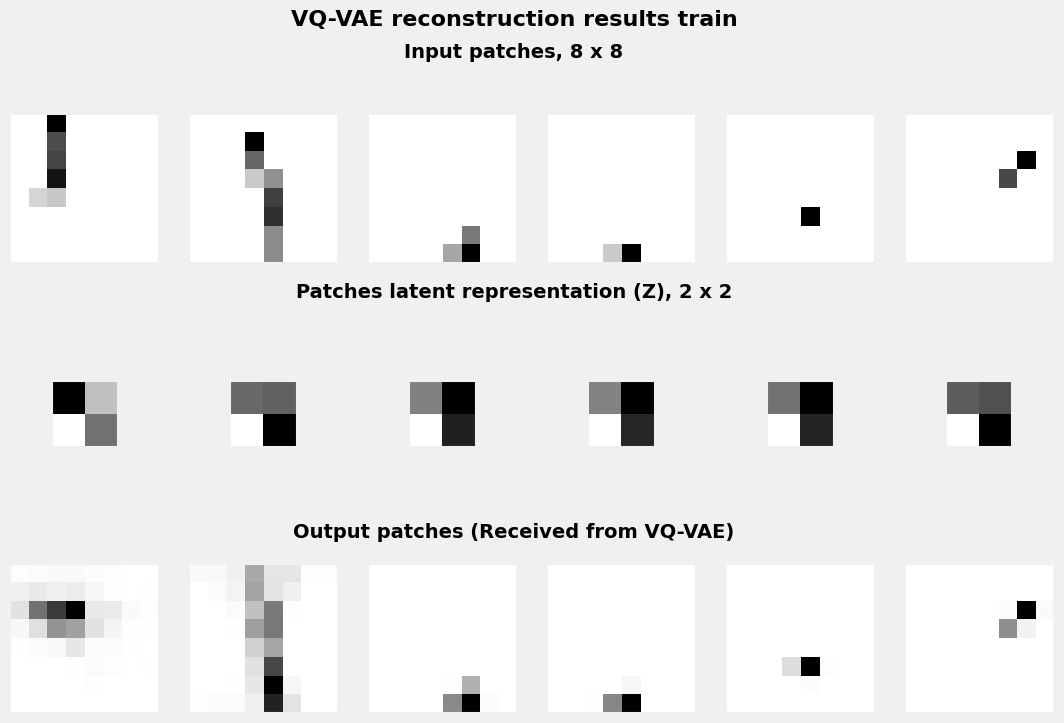

In [82]:
def plot_patches(patch_rows: list[tuple], title: str) -> None:
    cols = len(patch_rows[0][0])
    rows = len(patch_rows)

    # fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
    fig = plt.figure(figsize=(12, 8))
    gs = GridSpec(
        3, cols,
        height_ratios=[1.5, 0.5, 1.5]
    )
    fig.suptitle(
        title,
        fontsize=16,
        fontweight="bold",
        y=0.98
    )

    for i in range(rows):
        
        (patch_row, patch_row_title) = patch_rows[i]
        
        fig.text(
            0.5,                    # centered horizontally
            0.92 - i * 0.30,        # vertical position
            patch_row_title,
            ha='center',
            fontsize=14,
            fontweight='bold'
        )
        
        # row parts
        # part 1
        for j in range(cols):
            ax = fig.add_subplot(gs[i, j])
            
            ax.imshow(patch_row[j], cmap='gist_yarg', origin='lower')
            
            ax.set_xticks([])
            ax.set_yticks([])
            
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(1.5)
        

        plt.subplots_adjust(wspace=0.2, hspace=0.6)
    plt.show()
        
        
patch_rows = [
    (patches_before_train, "Input patches, 8 x 8"),
    (patches_z_train, "Patches latent representation (Z), 2 x 2"),
    (patches_after_train, "Output patches (Received from VQ-VAE)")
]

plot_patches(patch_rows, "VQ-VAE reconstruction results train")

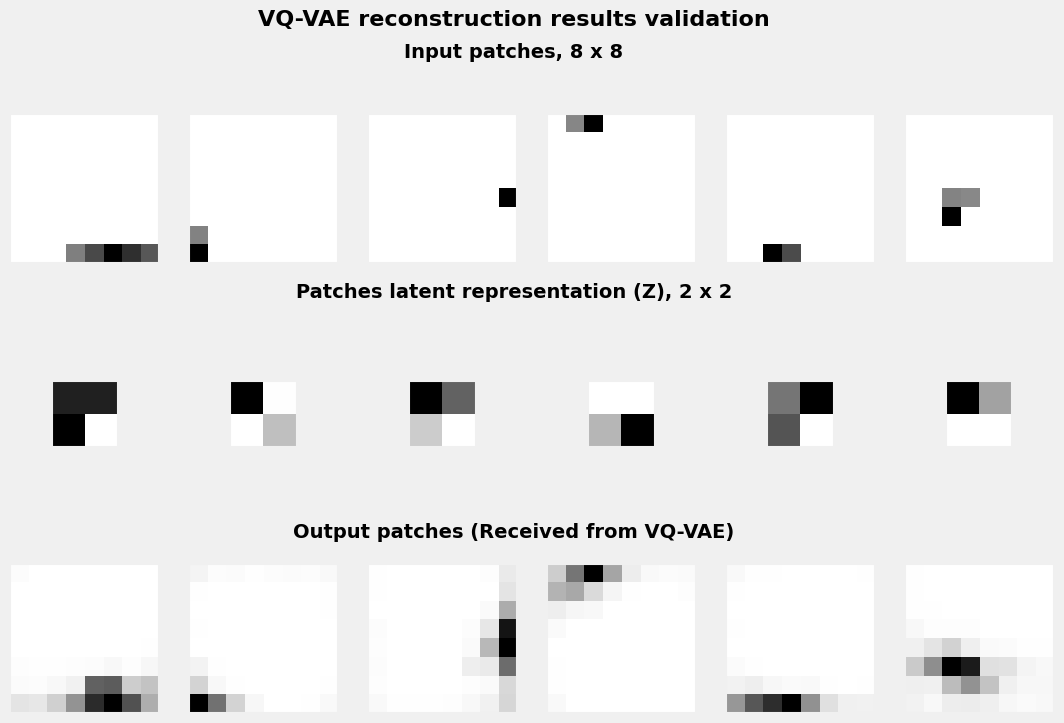

In [83]:
patch_rows = [
    (patches_before_val, "Input patches, 8 x 8"),
    (patches_z_val, "Patches latent representation (Z), 2 x 2"),
    (patches_after_val, "Output patches (Received from VQ-VAE)")
]

plot_patches(patch_rows, "VQ-VAE reconstruction results validation")

In [84]:
# TODO
# Improve gradients
_display_gradients(model)

Showing model gradients
encoder.0.weight 0.03733062371611595
encoder.1.weight 0.0023768844548612833
encoder.1.bias 0.0048902747221291065
encoder.3.weight 0.031110821291804314
encoder.4.weight 0.002417813055217266
encoder.4.bias 0.0018470283830538392
encoder.6.weight 0.020089760422706604
encoder.7.weight 0.0015666522085666656
encoder.7.bias 0.0019996173214167356
encoder.8.stack.0.res_block.1.weight 0.010811281390488148
encoder.8.stack.0.res_block.3.weight 0.007148153148591518
encoder.8.stack.1.res_block.1.weight 0.012394113466143608
encoder.8.stack.1.res_block.3.weight 0.0052851601503789425
vq_layer.embedding.weight 0.0003877111303154379
decoder.0.weight 0.006022708024829626
decoder.1.weight 0.0011507734889164567
decoder.1.bias 0.0006559595931321383
decoder.2.stack.0.res_block.1.weight 0.003745830385014415
decoder.2.stack.0.res_block.3.weight 0.005398436915129423
decoder.2.stack.1.res_block.1.weight 0.008365137502551079
decoder.2.stack.1.res_block.3.weight 0.01332737598568201
decoder.3.

VQ VAE, BCE encoder average loss values over epochs


/tmp/ipykernel_424207/1927438378.py:89: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


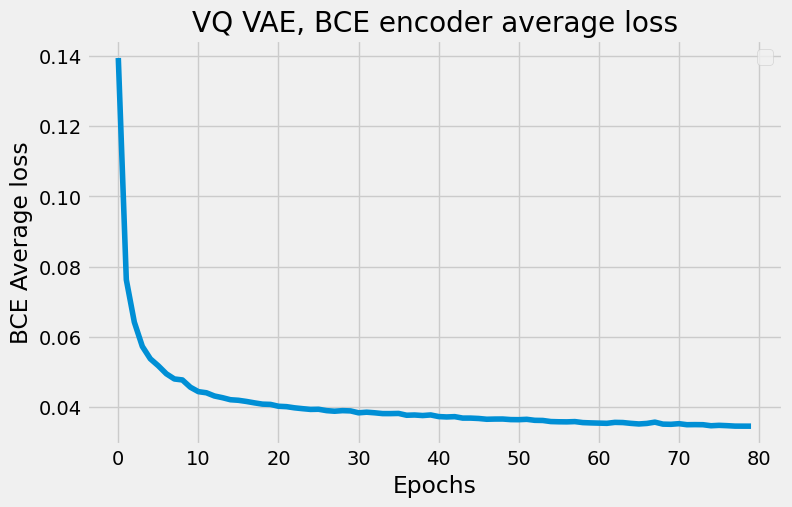

In [85]:
# display loss values
plot_metric_results(
    y_values=average_loss_train, 
    x_values=list(range(num_epochs)),
    y_title="BCE Average loss",
    title="VQ VAE, BCE encoder average loss",
    x_label="Epochs"
)

In [86]:
# print(f"mu = {model.z_log_mean.mean().item()}")
# print(f"logvar = {model.z_log_var.std().item()}")

In [87]:
# Test set for testing using unseen data
model.load_state_dict(torch.load("vqvae.pth"))
model.eval()

bce_loss_values_test = []

patch_display_limit = 8
patches_after_test = []
patches_before_test = []
patches_z = [] # latent vector

bce_total_value = 0
perplexity_total = 0
test_set_size = len(test_loader)

for patch_test in test_loader:
    patch_test = patch_test.to(device)                     
    (
        recon_patch, 
        codebook, 
        z_q, 
        perplexity,
        _
    ) = model(patch_test)
    
    perplexity_total += perplexity.item()
    
    if len(patches_after_test) < patch_display_limit:
        patch_test_np = patch_test[0][0].cpu().detach().numpy()
        patches_before_test.append(patch_test_np)
        
        recon_patch_np = recon_patch[0][0].cpu().detach().numpy()
        patches_after_test.append(recon_patch_np)
        z_np = _tensor_to_numpy(z_q[0][0])
        
        patches_z.append(z_np)
    
    # mse_loss = F.mse_loss(patch_test, recon_patch).item()
    bce_loss = F.binary_cross_entropy(
        patch_test, 
        recon_patch, 
        reduction="mean"
    ).cpu().detach().numpy().item()
    
    bce_total_value += bce_loss
    
bce_loss_average = bce_total_value / test_set_size
perplexity_average = perplexity_total / test_set_size

print(f"Based on test set (size = {test_set_size}), average BCE loss = {bce_loss_average:.5f}")
print(f"Based on test set (size = {test_set_size}), average codebook perplexity = {perplexity_average:.5f}/{num_embeddings}")

Based on test set (size = 25), average BCE loss = 0.27609
Based on test set (size = 25), average codebook perplexity = 24.73711/32


In [88]:
len(patches_before_test)

8

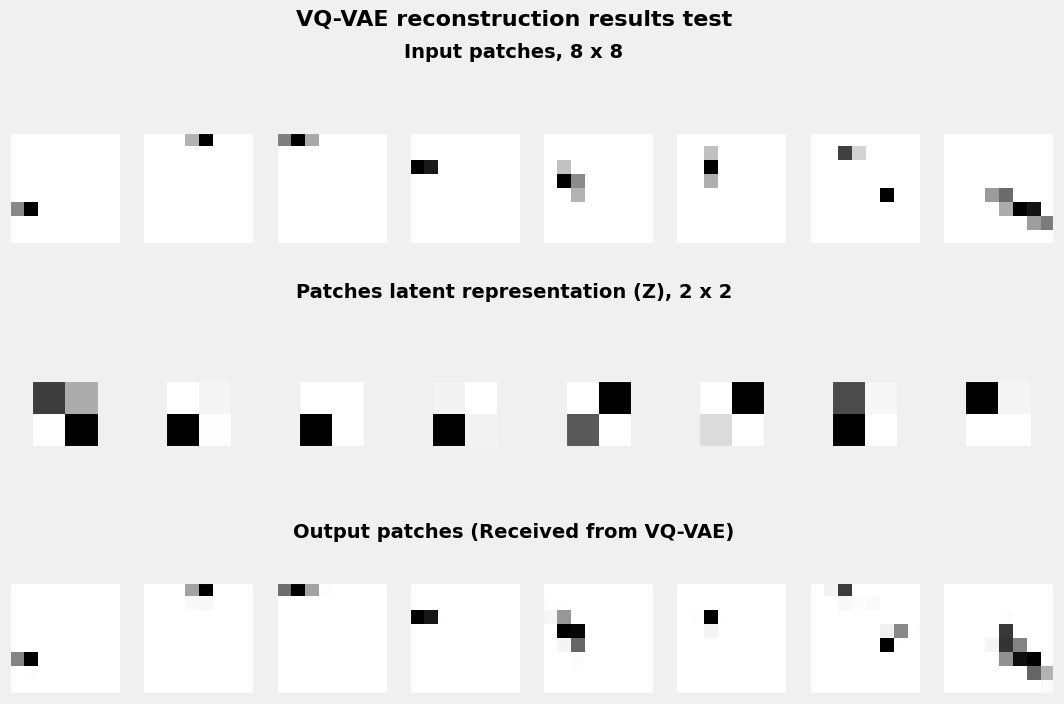

In [89]:
# Test dataset plotting part
patch_rows = [
    (patches_before_test, "Input patches, 8 x 8"),
    (patches_z, "Patches latent representation (Z), 2 x 2"),
    (patches_after_test, "Output patches (Received from VQ-VAE)")
]

plot_patches(patch_rows, "VQ-VAE reconstruction results test")

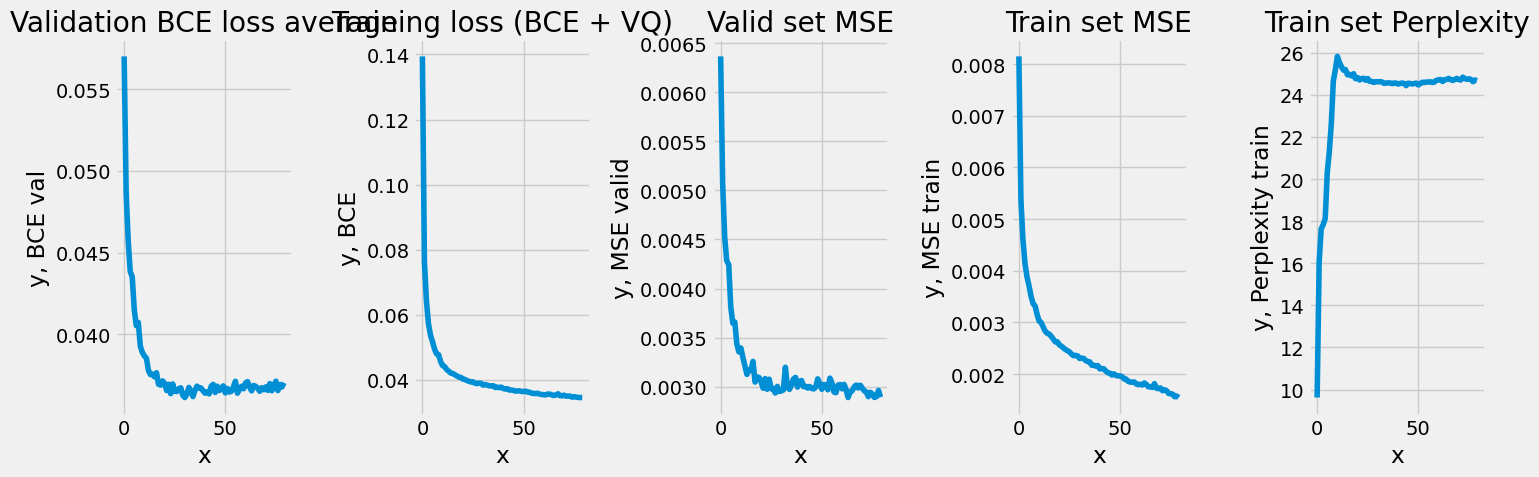

In [90]:
values_to_plot = [
    (list(range(len(average_loss_values_val))), average_loss_values_val, "Validation BCE loss average", "BCE val"),
    (list(range(len(average_loss_train))), average_loss_train, "Training loss (BCE + VQ)", "BCE"),
    (list(range(len(average_loss_valid_mse_val))), average_loss_valid_mse_val, "Valid set MSE", "MSE valid"),
    (list(range(len(average_loss_train_mse))), average_loss_train_mse, "Train set MSE", "MSE train"),
    (list(range(len(average_perplexity_train))), average_perplexity_train, "Train set Perplexity", "Perplexity train"),
]

fig, axes = plt.subplots(1, len(values_to_plot), figsize=(15, 5))

for i, (x, y, title, y_label) in enumerate(values_to_plot):
    axes[i].plot(
        x,
        y,
    )
    axes[i].grid(True)
    axes[i].set_title(title)
    axes[i].set_xlabel("x")
    axes[i].set_ylabel(f"y, {y_label}")
    
    for spine in axes[i].spines.values():
        spine.set_linewidth(2)

plt.tight_layout()
plt.show()

# print(title + " values over epochs")
# plt.style.use('fivethirtyeight')
# plt.figure(figsize=(8, 5))
# plt.plot(x_values, y_values, marker=marker)
# plt.xlabel(x_label)
# plt.ylabel(y_title)
# plt.legend()
# plt.title(title)
# plt.show()

Results:
<!-- * Perplexity shows that per patch about 10 from 16 codebook entries are used
* Reconstruction quality is about average. Representations with validation and test tests
look marginally similar to the input images
* Compression ratio shows that input image successfully was scaled about 3 times (~2.8).
* 1 encoded patch has 27 bits, while 1 encoded patch in VAE has 128 bits. 
* beta = 4e-3 (commitment cost) given better results. Beta needs to be very small and once smaller, gives better results. Based on official VQ-VAE research paper, image compression, requires beta to in the inverval [0.1, 2.0] -->
* Codebook entries from 16 vectors (rows), only approximately 8 codebook entries are used based perplexity
* Reconstruction improves with bigger latent vector and num embeddings. Reducing codebook size, improves usage but not reconstruction
* Validation set properly works with higher beta coeficient